In [ ]:
# Decision Tree on Iris
# -----------------------------------
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1) Load dataset
iris = load_iris()  #https://github.com/scikit-learn/scikit-learn/blob/98ed9dc73a86f5f11781a0e21f24c8f47979ec67/sklearn/datasets/data/iris.csv
                    #https://archive.ics.uci.edu/dataset/53/iris
X = iris.data
y = iris.target

# 2) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) Train Decision Tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 4) Predict
y_pred = clf.predict(X_test)

# Accuracy
acc_test = accuracy_score(y_test, y_pred)
print("acc_test :", acc_test)

# Training predictions
y_train_pred = clf.predict(X_train)
acc_train = accuracy_score(y_train, y_train_pred)
print("acc_train:", acc_train)




acc_test : 0.9666666666666667
acc_train: 0.9833333333333333


| Gap (%) | Meaning |
|--------|---------|
| < 3% | Very good / no overfitting |
| 3% – 7% | Mild overfitting |
| 7% – 12% | Moderate overfitting |
| > 12% | Strong overfitting |
| > 20% | Severe overfitting |


In [ ]:
DecisionTreeClassifier()



DecisionTreeClassifier()

In [ ]:
print(clf.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [ ]:
!apt-get install graphviz -y
!pip install graphviz


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


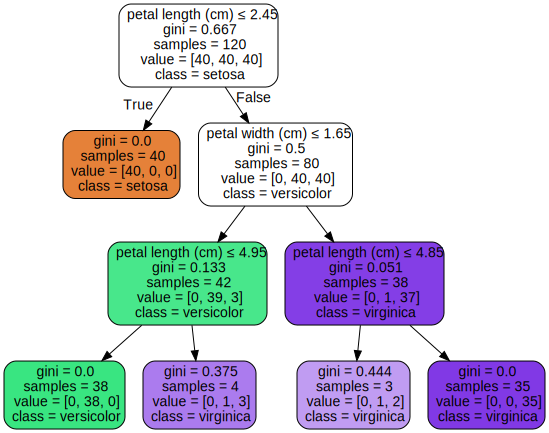

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Train shallow tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Export tree
dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

# Display
graph = graphviz.Source(dot_data)
graph


In [ ]:
import numpy as np
petal_length = X_train[:, 2]
vals = np.sort(X_train[:, 2])   # petal length column
print(vals)


[1.1 1.2 1.3 1.3 1.3 1.3 1.3 1.4 1.4 1.4 1.4 1.4 1.4 1.4 1.4 1.4 1.4 1.4
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.6 1.6 1.6 1.6 1.6 1.6 1.6
 1.7 1.7 1.9 1.9 3.  3.5 3.5 3.6 3.7 3.8 3.9 3.9 4.  4.  4.  4.  4.  4.1
 4.1 4.1 4.2 4.2 4.2 4.2 4.3 4.3 4.4 4.4 4.4 4.5 4.5 4.5 4.5 4.5 4.5 4.6
 4.6 4.7 4.7 4.7 4.8 4.8 4.8 4.9 4.9 4.9 4.9 5.  5.  5.  5.1 5.1 5.1 5.1
 5.1 5.1 5.1 5.2 5.3 5.3 5.4 5.4 5.5 5.5 5.6 5.6 5.6 5.7 5.7 5.7 5.8 5.8
 5.9 5.9 6.  6.  6.1 6.1 6.1 6.4 6.6 6.7 6.7 6.9]


In [ ]:
print(np.unique(vals))

[1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.9 3.  3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3
 4.4 4.5 4.6 4.7 4.8 4.9 5.  5.1 5.2 5.3 5.4 5.5 5.6 5.7 5.8 5.9 6.  6.1
 6.4 6.6 6.7 6.9]


In [ ]:
thresholds = (vals[:-1] + vals[1:]) / 2
print(thresholds)


[1.15 1.25 1.3  1.3  1.3  1.3  1.35 1.4  1.4  1.4  1.4  1.4  1.4  1.4
 1.4  1.4  1.4  1.45 1.5  1.5  1.5  1.5  1.5  1.5  1.5  1.5  1.5  1.5
 1.55 1.6  1.6  1.6  1.6  1.6  1.6  1.65 1.7  1.8  1.9  2.45 3.25 3.5
 3.55 3.65 3.75 3.85 3.9  3.95 4.   4.   4.   4.   4.05 4.1  4.1  4.15
 4.2  4.2  4.2  4.25 4.3  4.35 4.4  4.4  4.45 4.5  4.5  4.5  4.5  4.5
 4.55 4.6  4.65 4.7  4.7  4.75 4.8  4.8  4.85 4.9  4.9  4.9  4.95 5.
 5.   5.05 5.1  5.1  5.1  5.1  5.1  5.1  5.15 5.25 5.3  5.35 5.4  5.45
 5.5  5.55 5.6  5.6  5.65 5.7  5.7  5.75 5.8  5.85 5.9  5.95 6.   6.05
 6.1  6.1  6.25 6.5  6.65 6.7  6.8 ]


Feature: petal length (cm)
Best threshold (TRAIN): 2.45
Best weighted Gini after split (TRAIN): 0.3333333333333333


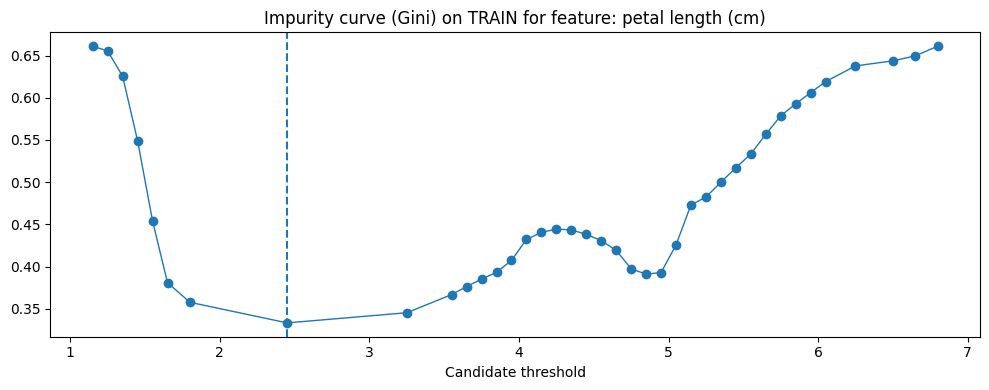

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Impurity curve on TRAINING set only
# -----------------------------------

# Choose a feature to analyze
# 0: sepal length, 1: sepal width, 2: petal length, 3: petal width
feature_idx = 2
feature_name = iris.feature_names[feature_idx]

# Use TRAIN split (no leakage)
x = X_train[:, feature_idx]
y_local = y_train

def gini_impurity(labels):
    if len(labels) == 0:
        return 0.0
    counts = np.bincount(labels)
    p = counts / counts.sum()
    return 1.0 - np.sum(p**2)

# Candidate thresholds (midpoints of sorted unique TRAIN values)
vals = np.unique(np.sort(x))
thresholds = (vals[:-1] + vals[1:]) / 2

# Compute weighted Gini after split for each threshold (on TRAIN only)
weighted_ginis = []
for t in thresholds:
    left = y_local[x <= t]
    right = y_local[x > t]
    w_left = len(left) / len(y_local)
    w_right = len(right) / len(y_local)
    wg = w_left * gini_impurity(left) + w_right * gini_impurity(right)
    weighted_ginis.append(wg)

weighted_ginis = np.array(weighted_ginis)

best_idx = np.argmin(weighted_ginis)
best_t = thresholds[best_idx]
best_wg = weighted_ginis[best_idx]

print("Feature:", feature_name)
print("Best threshold (TRAIN):", best_t)
print("Best weighted Gini after split (TRAIN):", best_wg)

# Plot impurity curve
plt.figure(figsize=(10, 4))
plt.plot(thresholds, weighted_ginis, marker='o', linewidth=1)
plt.axvline(best_t, linestyle='--')
plt.xlabel("Candidate threshold")
# plt.ylabel("Weighted Gini impurity (after split)")
plt.title(f"Impurity curve (Gini) on TRAIN for feature: {feature_name}")
plt.tight_layout()
plt.show()


acc_test : 1.0
acc_train: 1.0


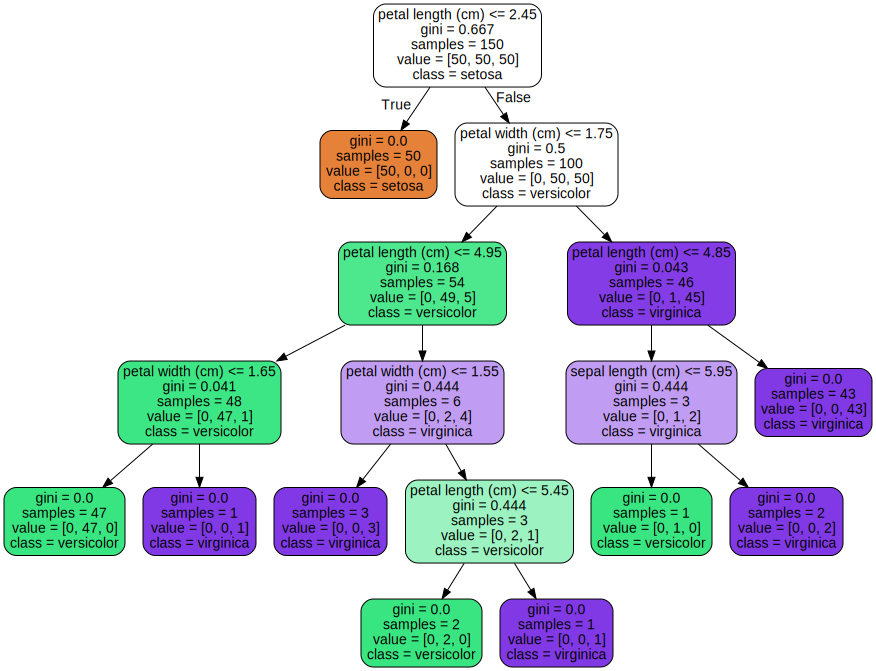

In [ ]:
clf_deep = DecisionTreeClassifier(random_state=42)
clf_deep.fit(X, y)

dot_data_deep = export_graphviz(
    clf_deep,
    out_file=None,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)



#  Predict + acc
y_pred = clf_deep.predict(X_test)

# Accuracy
acc_test = accuracy_score(y_test, y_pred)
print("acc_test :", acc_test)

# Training predictions & acc
y_train_pred = clf_deep.predict(X_train)
acc_train = accuracy_score(y_train, y_train_pred)
print("acc_train:", acc_train)


graphviz.Source(dot_data_deep)


In [ ]:
print(X.shape)

(150, 4)


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("Depth=3 CV accuracy:",
      np.mean(cross_val_score(clf, X, y, cv=5))) #It is equivalent to: KFold(n_splits=5)

print("Full tree CV accuracy:",
      np.mean(cross_val_score(clf_deep, X, y, cv=5)))


Depth=3 CV accuracy: 0.9733333333333334
Full tree CV accuracy: 0.9533333333333334
